# Regressão Logística SEM Validação de Premissas - Sklearn

## Bibliotecas e Configuração

In [1]:
# Dependências
import sys
#!{sys.executable} -m pip install --disable-pip-version-check -r ../requirements.txt -q
print('Bibliotecas instaladas')

Bibliotecas instaladas


In [2]:
# Dependências
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Manipulação dos dados
import pandas as pd
import numpy as np
from datetime import datetime
import os

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Diretórios
from configs.paths import *
from configs.function_basic import *
from configs.function_others import *

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Métricas e validação
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,precision_recall_curve,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Avisos
import warnings
warnings.filterwarnings('ignore')

# Configuração
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', None)

print('✅ Ambiente Configurado')

Diretórios carregados com sucesso
Funções básicas carregadas com sucesso
Funções extras carregadas com sucesso
✅ Ambiente Configurado


## Parâmetros Globais

In [3]:
# Definições
TARGET = 'FPD'
RANDOM_STATE = 42
THRESHOLD = 0.5
C = 0.1
DATA_EXECUCAO = datetime.now().strftime('%d-%m-%Y')
VERSAO = 'V1-2 - RL(Sklearn SEM Premissas)'

- V1-2 - normalização

- V1-7 - normalização + threshold (0.3)
- V1-8 - normalização + threshold (0.4)

## Carregamento dos Dados

In [4]:
# Carregar dados CORRIGIDOS conforme solicitado
train = pd.read_csv(PROCESSED_DIR / 'abt01_train.csv')
test = pd.read_csv(PROCESSED_DIR / 'abt01_test.csv')

print(f'📊 Treino: {train.shape}')
print(f'📊 Teste: {test.shape}')
print(f'\n🎯 Distribuição do Target (Treino):')
print(f"  Treino: {(train[TARGET].value_counts(normalize=True) * 100).round(2)}")

📊 Treino: (831081, 67)
📊 Teste: (389550, 67)

🎯 Distribuição do Target (Treino):
  Treino: 0    76.82
1    23.18
Name: FPD, dtype: float64


## Preparação dos Dados

In [5]:
# Backup dos dados originais
train_01 = train.copy()
test_01 = test.copy()

# lista de vars para retirar dos tratamentos
ignore_cols = ['SAFRA']

# Aplicando no treino
train_01 = train_01.drop(columns=ignore_cols)
test_01 = test_01.drop(columns=ignore_cols)

In [6]:
# Separar features e target
X_train = train_01.drop(TARGET, axis=1)
y_train = train_01[TARGET]

X_test = test_01.drop(TARGET, axis=1)
y_test = test_01[TARGET]

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

# Garantir mesmas features em treino e teste
features_common = X_train.columns.intersection(X_test.columns)
X_train = X_train[features_common]
X_test = X_test[features_common]

print(f'\n✅ Features alinhadas: {len(features_common)}')

X_train: (831081, 65)
X_test: (389550, 65)

✅ Features alinhadas: 65


## Normalização das Features

In [7]:
'''
# Dados não normalizados
X_train_scaled = X_train
X_test_scaled = X_test
'''

'\n# Dados não normalizados\nX_train_scaled = X_train\nX_test_scaled = X_test\n'

In [8]:
# Normalizar as features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter para DataFrame para manter nomes das features
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print('✅ Features Normalizadas')

✅ Features Normalizadas


## Treinamento do Modelo - Sklearn (Direto)

In [9]:
# Treinar modelo Logistic Regression com Sklearn (sem validações)
print('🤖 Treinando Regressão Logística (Sklearn - SEM premissas)...')
model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    C=C,
    n_jobs=-1,
    verbose=0
)

model.fit(X_train_scaled, y_train)
print('✅ Modelo treinado com sucesso!')

# Informações do modelo
print(f'\n📊 Informações do Modelo:')
print(f'Classes: {model.classes_}')
print(f'Coeficientes: {len(model.coef_[0])} features')
print(f'Intercepto: {model.intercept_[0]:.4f}')

🤖 Treinando Regressão Logística (Sklearn - SEM premissas)...
✅ Modelo treinado com sucesso!

📊 Informações do Modelo:
Classes: [0 1]
Coeficientes: 65 features
Intercepto: -0.1703


## Importância das Features

In [10]:
# Análise de coeficientes
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coeficiente': model.coef_[0]
})

feature_importance['Abs_Coef'] = np.abs(feature_importance['Coeficiente'])
feature_importance = feature_importance.sort_values('Abs_Coef', ascending=False)

print('\n📈 TOP 10 FEATURES MAIS IMPORTANTES:')
print(feature_importance.head(10)[['Feature', 'Coeficiente']].to_string(index=False))


📈 TOP 10 FEATURES MAIS IMPORTANTES:
  Feature  Coeficiente
 SCORE_02    -0.712391
   var_89    -0.301835
 SCORE_01    -0.253496
   var_87     0.096041
   var_86     0.087713
SCORE_MIN     0.085177
   var_91     0.081850
   var_56     0.079336
    IDADE     0.071200
   var_46    -0.070898


## Predições no Conjunto de Teste

In [11]:
# Fazer predições
print('🔮 Fazendo predições no conjunto de teste...')
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba >= THRESHOLD).astype(int)


print(f'✅ Predições concluídas!')
print(f'Proporção de classe 1: {y_pred.mean():.4f}')

🔮 Fazendo predições no conjunto de teste...
✅ Predições concluídas!
Proporção de classe 1: 0.4308


## Métricas de Avaliação

In [12]:
# Calcular métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print('\n📋 RELATÓRIO DE CLASSIFICAÇÃO:')
print(classification_report(y_test, y_pred, target_names=['Bom (0)', 'Mau (1)']))


📋 RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

     Bom (0)       0.86      0.63      0.73    301321
     Mau (1)       0.34      0.65      0.45     88229

    accuracy                           0.64    389550
   macro avg       0.60      0.64      0.59    389550
weighted avg       0.74      0.64      0.67    389550



## Matriz de Confusão


Confusion Matrix:


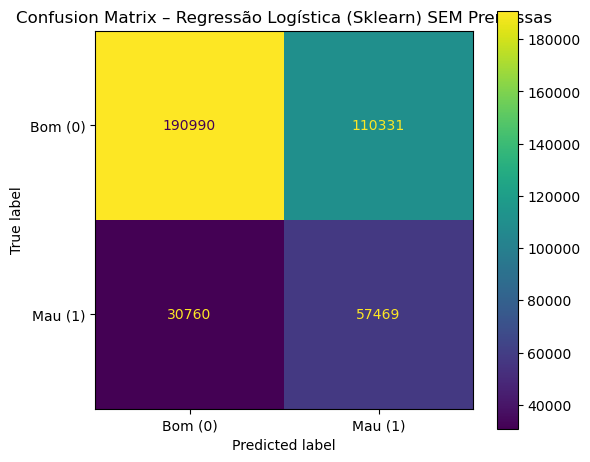

In [13]:
# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print('\nConfusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bom (0)', 'Mau (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format='d')
plt.title('Confusion Matrix – Regressão Logística (Sklearn) SEM Premissas')
plt.tight_layout()
plt.show()

## Salvamento das Métricas

In [14]:
# Criar registro de métricas
metrics_row = {
    'Precision': precision,
    'Recall': recall,
    'F1_score': f1,
    'AUC': auc,
    'TP': int(tp),
    'TN': int(tn),
    'FP': int(fp),
    'FN': int(fn),
    'Versao_Modelo': VERSAO,
    'Data_Execucao': DATA_EXECUCAO,
}

df_metrics = pd.DataFrame([metrics_row])

print('\n📊 MÉTRICAS DO MODELO:')
print(df_metrics.to_string(index=False))


📊 MÉTRICAS DO MODELO:
 Precision   Recall  F1_score      AUC    TP     TN     FP    FN                    Versao_Modelo Data_Execucao
  0.342485 0.651362  0.448926 0.696058 57469 190990 110331 30760 V1-2 - RL(Sklearn SEM Premissas)    09-02-2026


## Atualizar Arquivo de Métricas

In [15]:
# Salvar/atualizar metricas
path_metrics = METRICS_DIR / 'model_metrics.csv'

if os.path.exists(path_metrics):
    df_hist = pd.read_csv(path_metrics)
    
    # Se versão já existe, atualiza
    if VERSAO in df_hist['Versao_Modelo'].values:
        df_hist.loc[df_hist['Versao_Modelo'] == VERSAO] = df_metrics.iloc[0].values
    else:
        df_hist = pd.concat([df_hist, df_metrics], ignore_index=True)
else:
    df_hist = df_metrics

df_hist.to_csv(path_metrics, index=False)
print(f'✅ Métricas salvas em: {path_metrics}')

# Mostrar histórico de versões
print('\n📜 HISTÓRICO DE VERSÕES:')
df_hist = pd.read_csv(path_metrics)
df_hist = df_hist.sort_values('Data_Execucao', ascending=False)
print(df_hist[['Versao_Modelo', 'Precision', 'Recall', 'F1_score', 'AUC', 'TN', 'TP', 'FP', 'FN', 'Data_Execucao']].to_string(index=False))

OSError: Cannot save file into a non-existent directory: 'C:\pod\hackathon_pod_2025\ciencia\reports'

In [ ]:
# parar a execução do notebook a partir desta célula
raise SystemExit("Execução interrompida aqui por decisão de negócio")


## Grid

## 🔧 Combinações Válidas — Regressão Logística (Sklearn)

| Penalty      | Solvers compatíveis                 |
|--------------|-------------------------------------|
| `l2`         | `lbfgs`, `liblinear`, `sag`, `saga` |
| `l1`         | `liblinear`, `saga`                 |
| `elasticnet` | `saga`                              |
| `none`       | `lbfgs`, `sag`, `saga`              |  


> 💡 **Recomendação prática para crédito:**  
> Utilizar `penalty='l2'` com `solver='lbfgs'` para estabilidade, interpretabilidade e aderência a boas práticas de governança.


In [ ]:
'''
# Por exemplo, 10% dos dados
X_sample = X_train_scaled.sample(frac=0.1, random_state=42)
y_sample = y_train.loc[X_sample.index]
'''

In [ ]:
# Rodar grid final para comparar com V1 baseline

# Grid filtrado só com combinações válidas
param_grid = [
    {'penalty': ['l1'], 'solver': ['liblinear', 'saga'], 'C': [0.01, 0.1, 1, 10, 100], 'max_iter':[100,200]},
    {'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear', 'sag', 'saga'], 'C': [0.01, 0.1, 1, 10, 100], 'max_iter':[100,200]},
    {'penalty': ['elasticnet'], 'solver': ['saga'], 'C':[0.01,0.1,1,10,100], 'l1_ratio':[0.5], 'max_iter':[100,200]},  # l1_ratio = 0.5 default
    {'penalty': ['none'], 'solver': ['lbfgs', 'sag', 'saga'], 'max_iter':[100,200]}
]

# Modelo base
lr = LogisticRegression()

# GridSearchCV
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='f1',   # ou 'roc_auc' se preferir
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Rodar no dataset final
grid_search.fit(X_train, y_train)

# Pegar os melhores parâmetros
print(grid_search.best_params_)


Fitting 5 folds for each of 76 candidates, totalling 380 fits


## Threshold 

In [ ]:
# Encontrar o threshold que minimiza o custo financeiro total do crédito

# 1) Conjunto de thresholds a serem testados
thresholds = np.linspace(0.05, 0.95, 50)

# 2) Definição dos custos de negócio
# FP = negar um bom cliente (custo de oportunidade)
# FN = aprovar um mau cliente (inadimplência)
cost_fp = 1000
cost_fn = 10000

# 3) Armazena o custo total calculado para cada threshold
costs = []

# 4) Avaliação do custo para cada nível de corte
for t in thresholds:
    y_pred = (y_pred_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_cost = fp * cost_fp + fn * cost_fn
    costs.append(total_cost)

# 5) Seleção do threshold com menor impacto financeiro
best_threshold = thresholds[np.argmin(costs)]

# 6) Resultado final
print(f'Threshold ótimo por custo: {best_threshold:.4f}')


In [ ]:
# Escolher threshold garantindo um recall mínimo (proteção contra maus pagadores)

# 1) Curva Precision-Recall baseada nas probabilidades do modelo
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# 2) Meta de negócio: percentual mínimo de maus pagadores que queremos barrar
target_recall = 0.80

# 3) Identificar todos os thresholds que atingem ou superam esse recall
# (recall tem um elemento a mais que thresholds, por isso o recall[:-1])
valid_idxs = np.where(recall[:-1] >= target_recall)[0]

# 4) Escolher o MAIOR threshold possível dentro da meta
# → mais conservador, aprova menos clientes mantendo o recall exigido
best_idx = valid_idxs[-1]
best_threshold = thresholds[best_idx]

# 5) Resultado final da política de corte
print(f'Threshold escolhido: {best_threshold:.4f}')
print(f'Recall atingido: {recall[best_idx]:.4f}')
print(f'Precision resultante: {precision[best_idx]:.4f}')


In [ ]:
# Escolher threshold para atingir uma taxa de aprovação alvo (ex: 30%)

# 1) Gerar uma grade de thresholds possíveis
thresholds = np.linspace(0.01, 0.99, 99)

# 2) Para cada threshold, calcular a taxa de clientes aprovados
# (proporção de probabilidades acima do corte)
approval_rates = [(y_pred_proba >= t).mean() for t in thresholds]

# 3) Meta de negócio: percentual desejado de aprovação
target_approval = 0.30

# 4) Encontrar o threshold cuja taxa de aprovação fica mais próxima da meta
best_threshold = thresholds[
    np.argmin(np.abs(np.array(approval_rates) - target_approval))
]

# 5) Resultado final da política de aprovação
print(f'Threshold p/ aprovar ~30%: {best_threshold:.4f}')


## 📌 Resumo Executivo — Decisão de Aprovação de Crédito

O modelo de crédito organiza os clientes do **menos arriscado para o mais arriscado**.  
A decisão de **aprovar ou negar crédito** depende de um **nível de corte**, definido pela estratégia do negócio.

Esse nível de corte pode ser ajustado conforme o **apetite a risco**, o **objetivo comercial** e o **cenário econômico**.

---

## O que cada estratégia significa na prática

### 🛡️ Proteção financeira — Nível de corte: **0.23**
**Perfil:** extremamente conservador

**Na prática:**
- Você **barra a grande maioria dos maus pagadores**
- A empresa aceita **negar crédito para muitos bons clientes**
- Reduz fortemente inadimplência e prejuízo financeiro

**Leitura simples:**
> “Prefiro perder vendas do que assumir risco.”

---

### ⚖️ Equilíbrio risco × volume — Nível de corte: **0.41**
**Perfil:** conservador equilibrado

**Na prática:**
- Você **barra cerca de 80% dos maus pagadores** ✅
- De cada **10 clientes negados**, aproximadamente:
  - **3 realmente eram maus pagadores**
  - **7 eram bons clientes recusados** (custo comercial) ❗
- Mantém controle de risco sem travar totalmente as vendas

**Leitura simples:**
> “Protejo a carteira, mas continuo crescendo.”

---

### 🚀 Crescimento seletivo — Nível de corte: **0.56**
**Perfil:** agressivo em crescimento

**Na prática:**
- Você **aprova apenas os clientes de menor risco**
- A inadimplência esperada é menor
- O volume de vendas cai, mas a qualidade da carteira aumenta

**Leitura simples:**
> “Quero poucos clientes, mas muito bons.”

---

## Recomendações

- **Operação normal:** usar nível **0.41**  
  → melhor equilíbrio entre crescimento e controle de risco.
- **Cenário econômico adverso ou stress:** usar nível **0.23**  
  → foco total em preservação de caixa.
- **Campanhas premium ou funding caro:** usar nível **0.56**  
  → prioriza qualidade e margem.

---

## Mensagem-chave
O **modelo de crédito é o mesmo** em todos os cenários.  
O que muda é apenas a **política de aprovação**, definida pelo nível de corte.

Isso permite:
- flexibilidade operacional
- controle de risco
- rápida adaptação ao mercado
